In [1]:
!pip install -r ../requirements.txt

In [2]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())

12.8
True


In [ ]:
import sys
from collections import deque
import importlib
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.trial_algo as d3qn_per_agent
import configurations.config_p3_sub8 as config

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(d3qn_per_agent)
importlib.reload(config)

device used:  cuda


<module 'configurations.config_p3_sub7_v2' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p3_sub7_v2.py'>

In [ ]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.trial_algo import D3QN_PER
from configurations.config_p3_sub8 import config

In [5]:
print(config)

{'seed': 333, 'gamma': 0.99, 'bufferSize': 1000000, 'batchSize': 32, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.0001, 'MAX_TRAIN_EPISODES': 1000, 'MAX_EVAL_EPISODES': 5, 'updateFrequency': 20, 'explorationStrategyTrainFn': <function selectEpsilonGreedyActionREP_NOISY at 0x0000016580E354E0>, 'explorationStrategyEvalFn': <function selectGreedyActionREP_COMP at 0x0000016580E353A0>, 'max_steps': 1000, 'epsilon': 0.98, 'eps_decay_strategy': [('linear', {'s': 0, 'e': 499, 'ival': 1.0, 'fval': 0.4}), ('exponential', {'s': 500, 'e': 999, 'ival': 0.4, 'fval': 0.01})], 'device': device(type='cuda'), 'delta': 0.99, 'tau': 0.005, 'alpha': 0.58, 'beta': 0.42, 'beta_rate': 0.0002, 'f_hDim': [324, 256], 'lstm_hDim': 128, 'model_path': '../model_weights/model_weights_phase3_sub7_v2', 'loss_fn': 'HuberLoss', 'seq_len': 30, 'burn_in': 10, 'minSamples': 50, 'for_hDim': [224, 128], 'inv_hDim': [224, 128], 'alpha_f': 0.12, 'beta_i': 0.15, 'eta': 0.07, 'noise_std': 0.22}


In [15]:
def save_replay_buffer(buffer, filename="replay_buffer2.pth"):
    # Gather all relevant data
    buffer_data = {
        'buffer': list(buffer.buffer),  # list of episodes (each episode is list of tuples)
        'priorities': list(buffer.priorities),  # stepwise priorities per episode
        'prioritiesOverEpisodes': list(buffer.prioritiesOverEpisodes),  # episode-level priorities
        'temporaryBuffer': list(buffer.temporaryBuffer),  # unfinished current episode
        'temporaryPriorities': list(buffer.temporaryPriorities), 
        'bufferSize': buffer.bufferSize,
        'seqLen': buffer.seqLen,
        'batchSize': buffer.batchSize,
        'max_steps': buffer.max_steps,
        'alpha': buffer.alpha,
        'beta': buffer.beta,
        'beta_rate': buffer.beta_rate
    }
    torch.save(buffer_data, filename)
    print(f"[INFO] Replay buffer saved to {filename}")


def load_replay_buffer(buffer, filename="replay_buffer2.pth"):
    buffer_data = torch.load(filename, weights_only=False)
    
    buffer.buffer = deque(buffer_data['buffer'], maxlen=buffer_data['bufferSize'])
    buffer.priorities = deque(buffer_data['priorities'], maxlen=buffer_data['bufferSize'])
    buffer.prioritiesOverEpisodes = deque(buffer_data['prioritiesOverEpisodes'], maxlen=buffer_data['bufferSize'])
    buffer.temporaryBuffer = deque(buffer_data['temporaryBuffer'], maxlen=buffer_data['max_steps'])
    buffer.temporaryPriorities = deque(buffer_data['temporaryPriorities'], maxlen=buffer_data['max_steps'])
    
    # Restore configs
    buffer.bufferSize = buffer_data['bufferSize']
    buffer.seqLen = buffer_data['seqLen']
    buffer.batchSize = buffer_data['batchSize']
    buffer.max_steps = buffer_data['max_steps']
    buffer.alpha = buffer_data['alpha']
    buffer.beta = buffer_data['beta']
    buffer.beta_rate = buffer_data['beta_rate']
    
    print(f"[INFO] Replay buffer loaded from {filename}")

In [6]:
env1 = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=True,
    difficulty=3,
    box_speed=4,
)

env2 = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=False,
    difficulty=3,
    box_speed=4,
)

D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent = D3QN_PER(env1, env2, config)

In [16]:
# Save
save_replay_buffer(D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent.rBuffer, "rBuffer_checkpoint2.pth")

# Load (after restarting Python/VS Code)
load_replay_buffer(D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent.rBuffer, "rBuffer_checkpoint2.pth")

[INFO] Replay buffer saved to rBuffer_checkpoint2.pth
[INFO] Replay buffer loaded from rBuffer_checkpoint2.pth


In [7]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList1, d3qnPerEvalRewardsList2, d3qnPerWallClockTimeList, d3qnPerTotalStepsList = D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent.runD3QN_PER()

Episode 1: TR(without walls) -33868.000 | TT 13.969 | TS 1000
Episode 2: TR(without walls) -45198.000 | TT 28.775 | TS 1000
Episode 3: TR(with walls) -51999.000 | TT 41.315 | TS 927
Episode 4: TR(without walls) -16068.000 | TT 54.705 | TS 1000
Episode 5: TR(with walls) -52431.000 | TT 65.059 | TS 761
Episode 6: TR(without walls) -9670.000 | TT 79.483 | TS 1000
Episode 7: TR(without walls) 1993.000 | TT 81.301 | TS 124
Episode 8: TR(without walls) -46972.000 | TT 95.341 | TS 1000
Episode 9: TR(without walls) -84384.000 | TT 108.693 | TS 1000
Episode 10: TR(with walls) -43970.000 | TT 118.867 | TS 700
Episode 11: TR(without walls) -70985.000 | TT 133.919 | TS 1000
Episode 12: TR(with walls) -34167.000 | TT 144.449 | TS 1000
Episode 13: TR(without walls) 1861.000 | TT 146.465 | TS 271
Episode 14: TR(with walls) -15555.000 | TT 153.828 | TS 883
Episode 15: TR(without walls) -45800.000 | TT 169.372 | TS 1000
Episode 16: TR(with walls) -62777.000 | TT 184.705 | TS 1000
Episode 17: TR(without

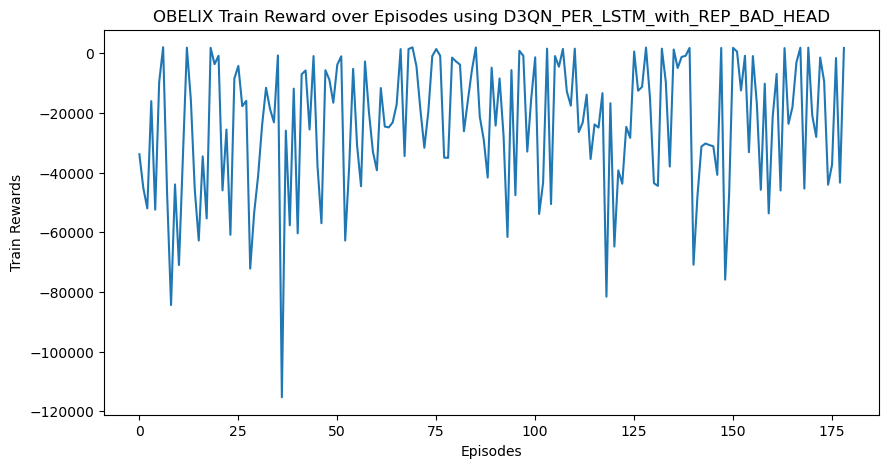

In [8]:
plotQuantity(
    d3qnPerTrainRewardsList,
    len(d3qnPerTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

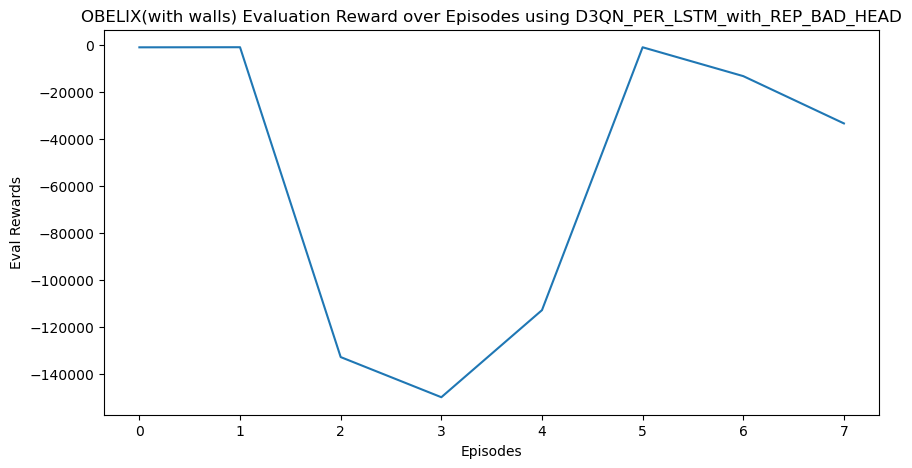

In [9]:
plotQuantity(
    d3qnPerEvalRewardsList1, 
    len(d3qnPerEvalRewardsList1), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX(with walls) Evaluation Reward over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

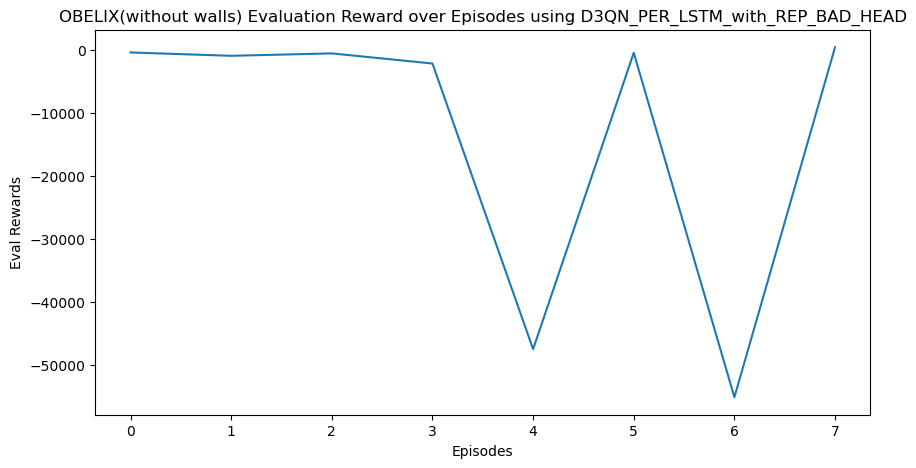

In [10]:
plotQuantity(
    d3qnPerEvalRewardsList2, 
    len(d3qnPerEvalRewardsList2), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX(without walls) Evaluation Reward over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

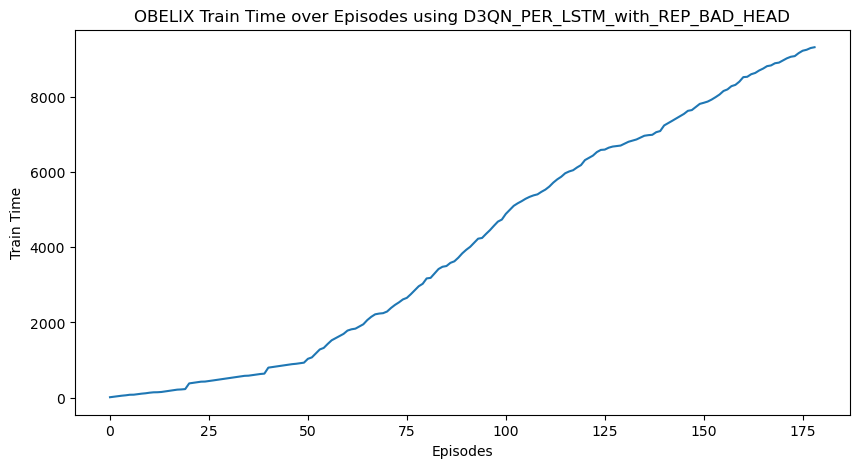

In [11]:
plotQuantity(
    d3qnPerTrainTimeList, 
    len(d3qnPerTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

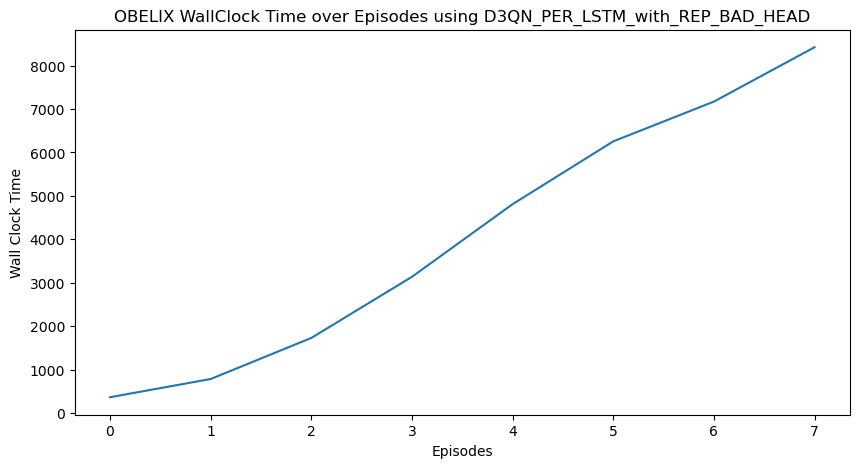

In [12]:
plotQuantity(
    d3qnPerWallClockTimeList, 
    len(d3qnPerWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

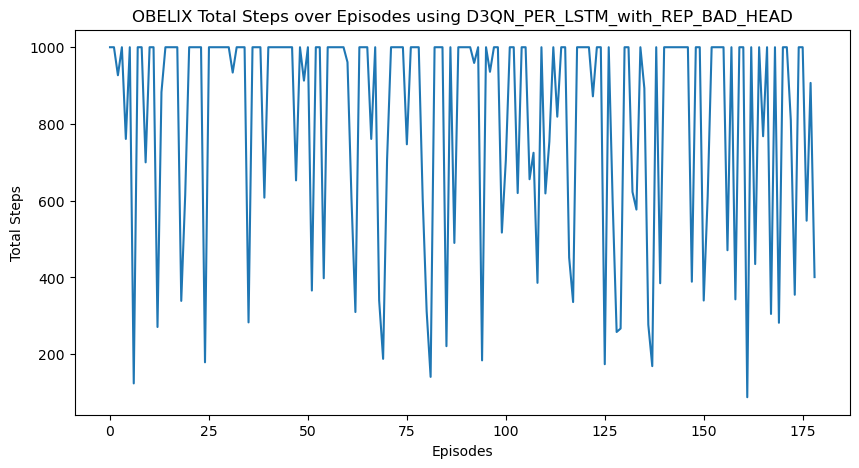

In [13]:
plotQuantity(
    d3qnPerTotalStepsList, 
    len(d3qnPerTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)